# Low-Rank Approximation of Images via Spectral Filtering

This notebook implements example 3.3: low-rank approximation of images via spectral filtering, using the QSVT. Required for this notebook are the following packages,

In [83]:
import QSP
import pennylane as qml
import qiskit
from qiskit.quantum_info import Statevector, Operator
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import CXGate, RZGate, UnitaryGate
import pyqsp
from pyqsp import response
import scipy
import numpy as np
from numpy.polynomial import Chebyshev
import matplotlib.pyplot as plt

def plotPoly(poly, n = 2001, domain = [-1, 1]):
    x = np.linspace(-1, 1, n)
    y = poly(x)

    plt.scatter(x, y, s=1, c="black")
    plt.xlabel("x")
    plt.xlim(domain[0], domain[1])
    plt.ylabel("P(x)")
    plt.ylim(-1.2, 1.2)
    plt.grid(True)
    plt.show()

def blockMat(mat):
    return np.block([[mat, scipy.linalg.sqrtm(np.eye(mat.shape[0]) - mat @ mat.T)], [scipy.linalg.sqrtm(np.eye(mat.shape[1]) - mat.T @ mat), -1 * mat.T]])

This notebook was tested in Python 3.11.9 with the latest versions of the above packages.

#### Polynomial

First we create the polynomial approximation of,

\begin{equation}
f(x) = \begin{cases}
        x,& x< -\tau \\
        0,& -\tau \leq x \leq \tau\\
        x,& x\geq \tau.
    \end{cases}
\end{equation}

In [84]:
from numpy.polynomial import Chebyshev

# Degree of the polynomial
N = 100
# Threshold
tau = 0.02

# Array of Chebyshev polynomial coefficients
coeff = np.zeros(N+1)

n = np.array(range(2,N+1))

coeff[0] = np.sin(np.arccos(tau)) / np.pi
coeff[1] = (2 * np.arccos(tau) + np.sin(2 * np.arccos(tau))) / 2 / np.pi
coeff[2:] = 2 / (np.pi * (n**2 - 1)) * (n * tau * np.sin(n * np.arccos(tau)) - np.sqrt(1 - tau ** 2) * np.cos(n * np.arccos(tau)))

# Chebyshev polynomial
poly = Chebyshev(coeff)

Checking that our polynomial is a good approximation of the step function,

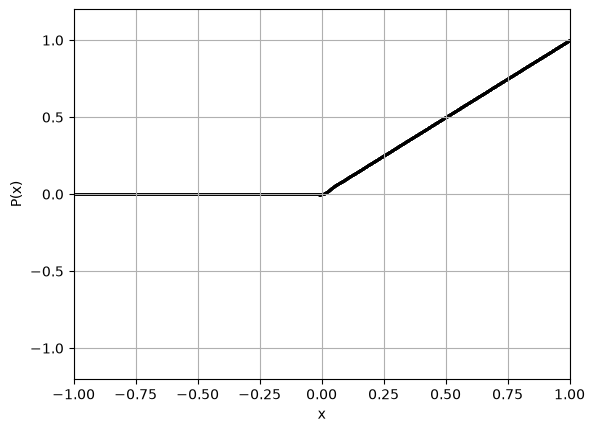

In [85]:
plotPoly(poly)

Of the above full polynomial, we only need the odd component

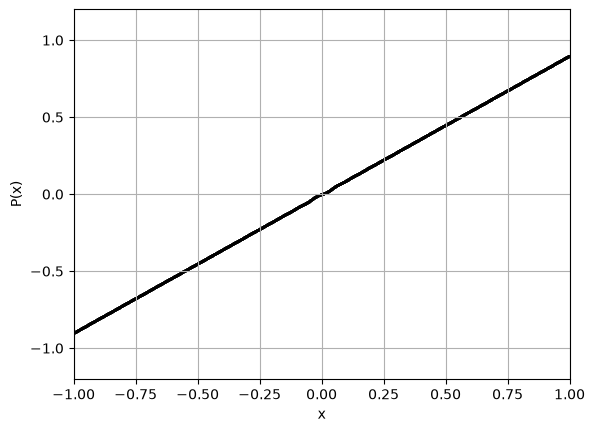

In [86]:
# Take the odd terms
oddCoeff = coeff.copy() * 1.8
oddCoeff[::2] = 0

oddPoly = Chebyshev(oddCoeff)

plotPoly(oddPoly)

#### Phase

We next convert the poly coefficients into a set of phases. We will use a modified version of the algorithm used to find the phases for GQSP. While this is much faster, we also require our polynomial to be bounded on the unit circle,

$$
\forall \theta\in[0,2\pi),\; |P(e^{i\theta})|\le 1

$$

In [87]:
oddPoly

Chebyshev([ 0.00000000e+00,  8.99996944e-01,  0.00000000e+00,  9.16549107e-06,
        0.00000000e+00, -1.52660419e-05,  0.00000000e+00,  2.13519397e-05,
        0.00000000e+00, -2.74173467e-05,  0.00000000e+00,  3.34564485e-05,
        0.00000000e+00, -3.94634608e-05,  0.00000000e+00,  4.54326360e-05,
        0.00000000e+00, -5.13582695e-05,  0.00000000e+00,  5.72347068e-05,
        0.00000000e+00, -6.30563492e-05,  0.00000000e+00,  6.88176607e-05,
        0.00000000e+00, -7.45131741e-05,  0.00000000e+00,  8.01374971e-05,
        0.00000000e+00, -8.56853188e-05,  0.00000000e+00,  9.11514152e-05,
        0.00000000e+00, -9.65306555e-05,  0.00000000e+00,  1.01818008e-04,
        0.00000000e+00, -1.07008545e-04,  0.00000000e+00,  1.12097448e-04,
        0.00000000e+00, -1.17080017e-04,  0.00000000e+00,  1.21951670e-04,
        0.00000000e+00, -1.26707952e-04,  0.00000000e+00,  1.31344537e-04,
        0.00000000e+00, -1.35857238e-04,  0.00000000e+00,  1.40242004e-04,
        0.00000000e+0

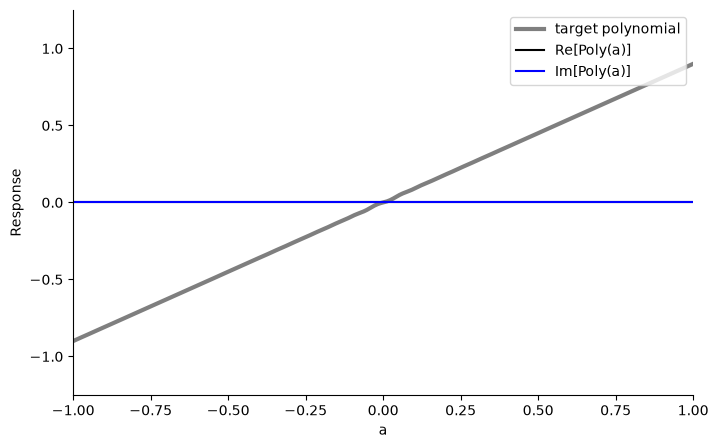

In [88]:
from pyqsp import response

# Calculate the phases
oddPhase = QSP.compute_angles(oddCoeff)

# Check the real part of the function (should overlap with the target polynomial)
response.PlotQSPResponse(
    oddPhase,
    pcoefs=oddCoeff)

#oddPhase = qml.transform_angles(oddPhase, "QSP", "QSVT")

#### Image and Block-encoding

Importing our image/matrix,

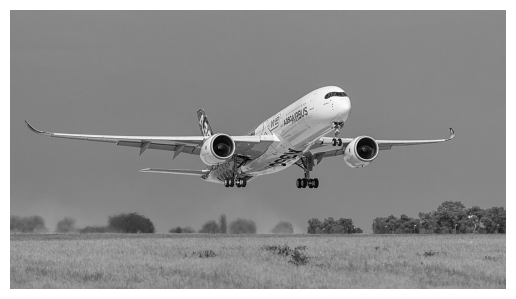

In [89]:
from matplotlib.image import imread

img = imread("data/airplane.jpg")

def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

img = rgb2gray(img)

plt.imshow(img, cmap = "gray")
plt.axis(False)
plt.show()

We can add some noise to the image. The noise is generally represented in the smallest singular values, so the filtering process should remove it

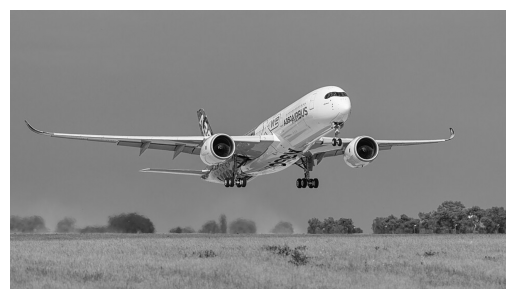

In [90]:
noisyImg = img + 0.05 * np.random.normal(size=img.shape)

plt.imshow(noisyImg, cmap = "gray")
plt.axis(False)
plt.show()

Our image's dimensions aren't powers of 2, so we will pad each dimension to a power of 2,

In [91]:
noisyImg.shape

(540, 960)

In [92]:
size = 2 ** int(max(np.ceil(np.log2(img.shape))))
padImg = np.zeros((size, size))
padImg[:img.shape[0], :img.shape[1]] = noisyImg

padImg.shape

(1024, 1024)

We need to block-encode our matrix to make it unitary. Generally you need to find an efficient block-encoding dependant on your matrix but we will use,

$$
U_A = \begin{pmatrix}
        A & \sqrt{I-AA^\dag} \\
        \sqrt{I-A^\dag A} & -A^\dag
      \end{pmatrix}
$$

with the requirement that $||A||_2\le1$

In [93]:
# Normalised the image matrix
imgScale = np.linalg.norm(padImg, ord=2)
normImg = padImg / imgScale

# U_img
U_img = np.block([[normImg, scipy.linalg.sqrtm(np.eye(normImg.shape[0]) - normImg @ normImg.T)], [scipy.linalg.sqrtm(np.eye(normImg.shape[1]) - normImg.T @ normImg), -1 * normImg.T]])

#### Classical Test

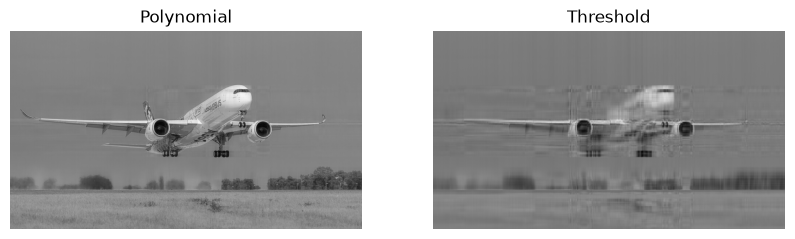

In [94]:
# Polynomial Threshold Approximation
# We use the normalised image so our singular value are [-1, 1], where our function is defined
U, S, Vh = np.linalg.svd(normImg, full_matrices=True)

SMat = np.zeros(normImg.shape)
np.fill_diagonal(SMat, oddPoly(S))

polyImg = U @ SMat @ Vh

# Classical Threshold
SMat = np.zeros(normImg.shape)
thresholdS = np.where(S < tau, 0, S)
np.fill_diagonal(SMat, thresholdS)

thresholdImg = U @ SMat @ Vh

# Plots
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

ax[0].imshow(polyImg[:noisyImg.shape[0], :noisyImg.shape[1]], cmap = "gray")
ax[0].set_title("Polynomial")
ax[0].axis(False)

ax[1].imshow(thresholdImg[:noisyImg.shape[0], :noisyImg.shape[1]], cmap = "gray")
ax[1].set_title("Threshold")
ax[1].axis(False)

plt.show()

#### Quantum Circuit

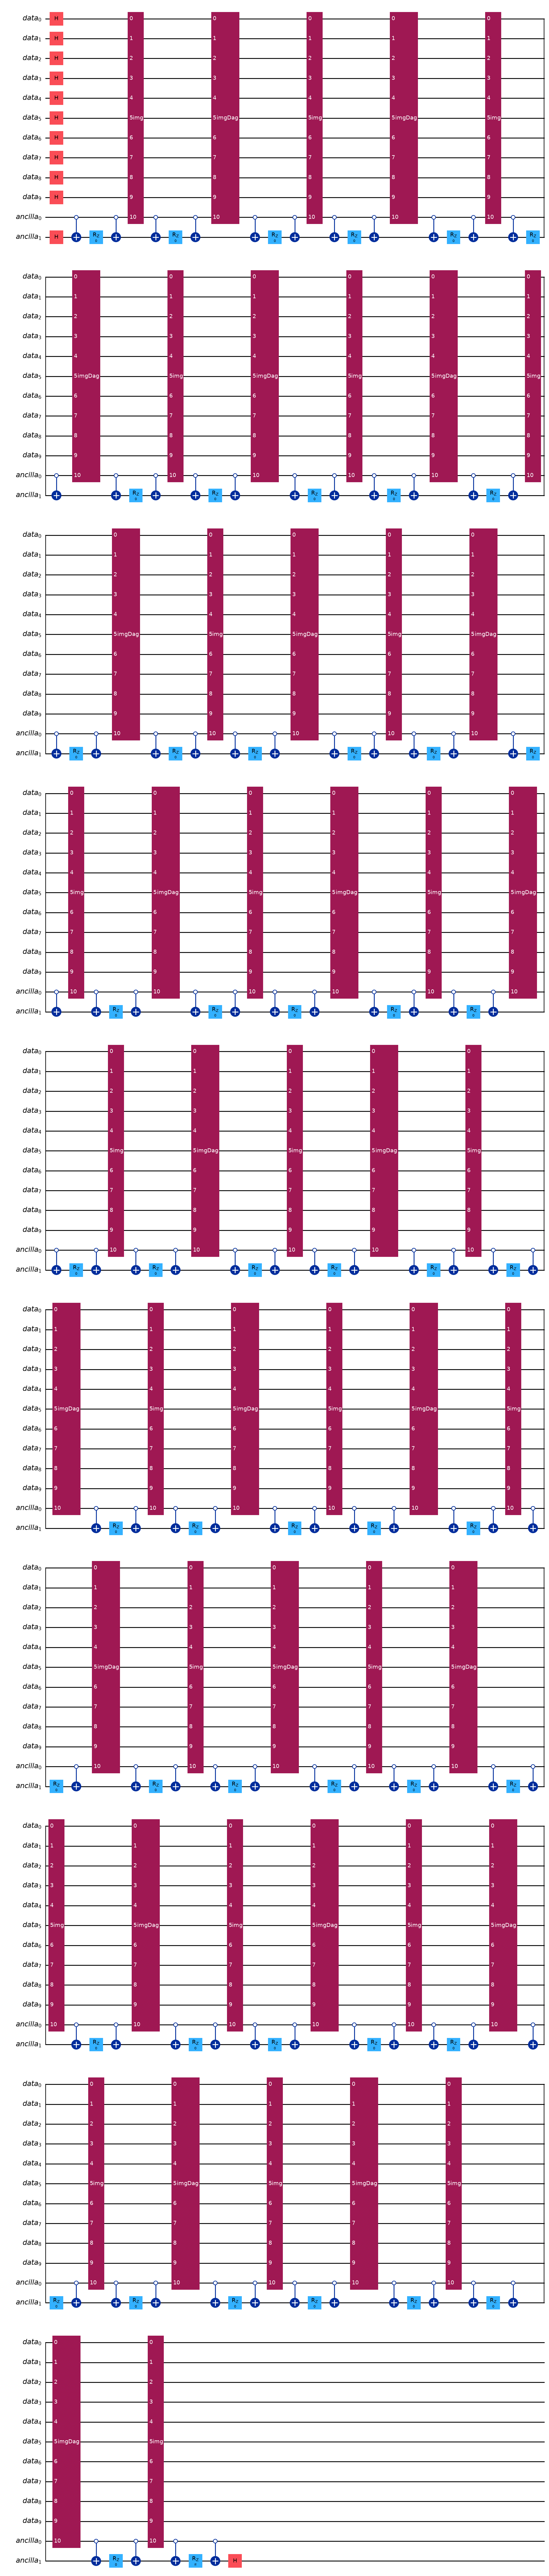

In [99]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import CXGate, RZGate, UnitaryGate
from qiskit.quantum_info import Operator

mat = U_img
phi = oddPhase

dataReg = QuantumRegister(int(np.ceil(np.log2(mat.shape[1]) - 1)), name="data")
ancillaReg = QuantumRegister(2, name="ancilla")

def QSVT_circuit_qiskit(mat, phi, registers):
    "mat: The normalised block-encoded matrix with the target matrix in the top left corner. "
    "phi: The phase angles for the QSVT circuit. "
    "registers: A tuple of (dataReg, ancillaReg)"


    dataReg, ancillaReg = registers

    qc = QuantumCircuit(dataReg, ancillaReg)

    imgGate = UnitaryGate(mat, label="img")
    imgGateDag = imgGate.adjoint()
    imgGateDag.label = "imgDag"

    qc.h(ancillaReg[-1])

    # Test Input State
    qc.h(dataReg)

    for i in range(int(len(phi)/2 - 1)):
        # Projector to block-encoding and rotation. Note we require double the angle of a regular RZ gate
        qc.mcx(ancillaReg[0:-1], ancillaReg[-1], ctrl_state="0")
        qc.rz(phi[2*i] * 2, ancillaReg[-1])
        qc.mcx(ancillaReg[0:-1], ancillaReg[-1], ctrl_state="0")

        # Applies U_img
        qc.append(imgGate, dataReg[:] + [ancillaReg[0]])

        qc.mcx(ancillaReg[0:-1], ancillaReg[-1], ctrl_state="0")
        qc.rz(phi[2*i + 1] * 2, ancillaReg[-1])
        qc.mcx(ancillaReg[0:-1], ancillaReg[-1], ctrl_state="0")

        qc.append(imgGateDag, dataReg[:] + [ancillaReg[0]])

    qc.mcx(ancillaReg[0:-1], ancillaReg[-1], ctrl_state="0")
    qc.rz(phi[-2] * 2, ancillaReg[-1])
    qc.mcx(ancillaReg[0:-1], ancillaReg[-1], ctrl_state="0")

    # Final block for odd polynomial
    qc.append(imgGate, dataReg[:] + [ancillaReg[0]])
        
    qc.mcx(ancillaReg[0:-1], ancillaReg[-1], ctrl_state="0")
    qc.rz(phi[-1] * 2, ancillaReg[-1])
    qc.mcx(ancillaReg[0:-1], ancillaReg[-1], ctrl_state="0")

    qc.h(ancillaReg[-1])

    return qc

qc = QSVT_circuit_qiskit(U_img, oddPhase, (dataReg, ancillaReg))

qc.draw(output='mpl')